# CS5489 - Machine Learning
# Lecture 9b - Unsupervised Learning - Clustering
### Dept. of Computer Science, City University of Hong Kong

# Outline
1. Unsupervised Learning
2. Parametric clustering
    1. K-means
    2. Gaussian mixture models (GMMs)
    3. Bayesian GMMs
3. **Non-parametric clustering and Mean-shift**
4. Spectral clustering

In [1]:
# setup
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
from mpl_toolkits.mplot3d import Axes3D

In [2]:
random.seed(38)
mu1 = array([0,0])
mu2 = array([6,8])
st1 = 2*random.normal(0,1,(2,2))
st2 = 2*random.normal(0,1,(2,2))
X1 = dot(random.normal(0,1,[60, 2]), st1.T) + mu1
X2 = dot(random.normal(0,1,[60, 2]), st2.T) + mu2
Xfull = r_[X1,X2]
axboxfull = [-10, 20, -7, 20]

X = Xfull
axbox = axboxfull
ssize = 16

In [3]:

mycmap = matplotlib.colors.ListedColormap(["#FF0000", "#00FF00", "#0000FF"])
cols = ['r', 'g', 'b']
jet = plt.get_cmap('jet')
rbow = plt.get_cmap('rainbow')

al = 0.4
rbow_data2 = {
    'red': lambda x:   (1-al) + al*abs(2 * x - 0.5),
    'green': lambda x: (1-al) + al*sin(x * pi),
    'blue': lambda x:  (1-al) + al*cos(x * pi / 2),
} 
rbow2 = matplotlib.colors.LinearSegmentedColormap('rainbow2', rbow_data2)

# ax is the axis
# cmap is colormap to use
# cl is the index of components to show [default is None which means all components]
def make_ellipses(means, covars, ax, cmap, cl=None, alphamul=1., showedge=False):
    dim = means.shape[1]
    if cl is None:
        cl = range(means.shape[0])
    for n in cl:
        mycv = covars[n]
        if mycv.size==1:
            mycv = mycv*eye(dim)
        elif mycv.size==dim:
            mycv = diag(mycv)
            
        v, w = linalg.eigh(mycv)

        u = w[0] / linalg.norm(w[0])
        angle = arctan2(u[1], u[0])
        angle = 180 * angle / pi  # convert to degrees
        s   = sqrt(v)  # stddev
        
        for f in [1,2,3]:
            ss = s*f  
            eopts = {}
            if showedge:
                eopts['edgecolor'] = 'k'
            else:
                eopts['edgecolor'] = None
            ell = matplotlib.patches.Ellipse(means[n, :2], 2*ss[0], 2*ss[1],
                                      angle=180 + angle, facecolor=cmap(float(n)/(lambda a,b: a if a>b else b)(max(cl),1)), 
                                     **eopts)
            ell.set_clip_box(ax.bbox)
            ell.set_alpha(0.15*alphamul)
            ax.add_artist(ell)

def plot_clusters(model, axbox, X, Y, pcmap, ccmap, showregions=False):
    # model = kmeans, gmm, dpgmm
    # X = points
    # pcmap = colormap for points
    # ccmap = colormap for centers
    
    name = model.__class__.__name__
    
    if (name == 'KMeans'):
        cc = model.cluster_centers_
        cl = range(model.n_clusters)
        cv = None
    elif (name == 'GMM') or (name == 'GaussianMixture'):
        cc = model.means_
        cl = range(model.n_components)
        cv = model.covariances_
    elif (name == 'DPGMM') or (name == 'BayesianGaussianMixture'):
        cl = unique(Y)        # find active clusters
        cc = model.means_[cl] # get means
        cv = model.covariances_[cl]
    elif (name == 'VBGMM'):
        cl = unique(Y)        # find active clusters
        cc = model.means_[cl] # get means
        cv = None
    elif (name == 'MeanShift'):
        cc = model.cluster_centers_
        cl = range(len(cc))
        cv = None
    elif (name == 'SpectralClustering'):
        cc = None
        cl = range(model.n_clusters)
        cv = None
    elif (name == 'DBSCAN'):
        cc = None
        cv = None
        cl = unique(model.labels_)
        cl = cl[cl != -1]
        core_mask = zeros_like(Y, dtype=bool)
        core_mask[model.core_sample_indices_] = True
        outlier_mask = (Y == -1)
        noncore_mask = logical_not(core_mask) & logical_not(outlier_mask)
        
    if showregions:    
        dx = axbox[1]-axbox[0]
        dy = axbox[3]-axbox[2]
        
        axbox2 = [ axbox[0]-0.5*dx, axbox[1]+0.5*dx,
                   axbox[2]-0.5*dy, axbox[3]+0.5*dy]
        
        # grid of points
        xr = [linspace(axbox2[0],axbox2[1],300), 
              linspace(axbox2[2],axbox2[3],300)]
        xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
        allpts = c_[xgrid0.ravel(), xgrid1.ravel()]
        
        # predictions
        Ypred = model.predict(allpts).reshape(xgrid0.shape)
        
        plt.imshow(Ypred, origin='lower', extent=axbox2, aspect='auto', 
           vmin=min(cl), vmax=max(cl), alpha=0.2, cmap=pcmap)

    # show ellipses
    if (cv is not None) and (not showregions):  
        make_ellipses(cc, cv, plt.gca(), pcmap, None)
    
    # show points
    if X is not None:
        if (name == 'DBSCAN'):
            plt.scatter(X[core_mask,0], X[core_mask,1], c=Y[core_mask], cmap=pcmap, label='core points', edgecolors='k')
            plt.scatter(X[noncore_mask,0], X[noncore_mask,1], c=Y[noncore_mask], 
                        cmap=pcmap, label='border points',
                        vmin=min(cl), vmax=max(cl), marker='v', edgecolors='k')
            plt.scatter(X[outlier_mask,0], X[outlier_mask,1], color='k', label='noise', s=6, edgecolors='k') 
        else:
            plt.scatter(X[:,0], X[:,1], c=Y, cmap=pcmap, edgecolors='k', s=ssize)
    
    # show centers
    if cc is not None:
        plt.scatter(cc[:,0], cc[:,1], c=cl, s=250, cmap=ccmap, marker='*', edgecolors='k')

    plt.axis('equal');  plt.axis(axbox);  plt.grid(True)  
        
    # return number of clusters found
    return (len(cl),)

In [4]:
def plot_scores(model, axbox, mycmap, showlabels=True, showcontour=True):
    xr = [ linspace(axbox[0], axbox[1], 200), 
           linspace(axbox[2], axbox[3], 200) ]

    # make a grid for calculating the posterior, 
    #  then form into a big [N,2] matrix
    xgrid0, xgrid1 = meshgrid(xr[0], xr[1])
    allpts = c_[xgrid0.ravel(), xgrid1.ravel()]

    # calculate scores
    prob = model.score_samples(allpts)
    prob1 = exp(prob.reshape(xgrid0.shape))

    # contour plot of the posterior and decision boundary
    plt.imshow(prob1, origin='lower', extent=axbox, alpha=0.50, cmap=mycmap)
    if showlabels:
        plt.colorbar(shrink=0.6)
    #levels=[0.1, 0.3, 0.7, 0.9]
    if showcontour:
        CS = plt.contour(xr[0], xr[1], prob1, cmap=mycmap, alpha=0.8)
#    if showlabels:
#        #plt.colorbar(CS)
#        plt.clabel(CS, inline=1, fontsize=10)
#    plt.contour(xr[0], xr[1], post1, levels=[0.5], linestyles='dashed', colors='black')



# Non-parametric densities
- Suppose we have samples $\{\mathbf{x}_1,\cdots,\mathbf{x}_N\}$
  - We want to estimate a probability density without assuming a parametric model (e.g., Gaussian)

In [5]:
X = Xfull
fig = plt.figure(figsize=(5,4))
plt.scatter(X[:,0], X[:,1], c='b', s=ssize, edgecolors='k')
plt.axis(axbox)
plt.axis('equal')
plt.grid(True)
plt.close()

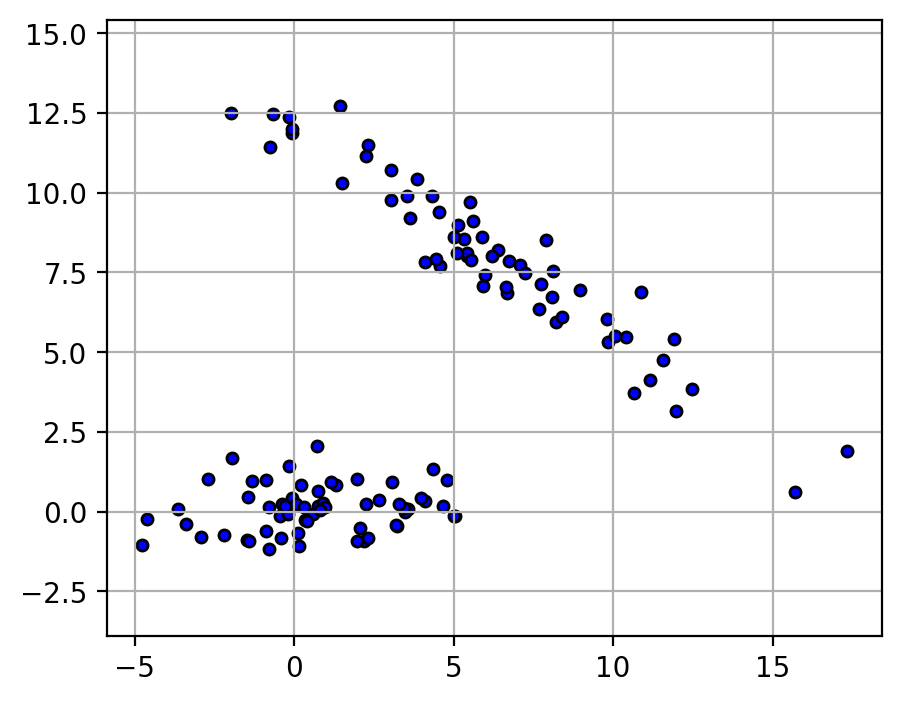

In [6]:
fig

# Non-parametric estimation
- Idea: put a small Gaussian at each data point, and sum it up.
  - each point contributes locally to the probability density.
  - $p(\mathbf{x}) = \frac{1}{N}\sum_{i=1}^N {\cal N}(\mathbf{x} | \mathbf{x}_i, \sigma^2 \mathbf{I})$
    - $\sigma$ is the bandwidth of the Gaussian.

In [7]:
fig = plt.figure(figsize=(10,4))
mycmap = matplotlib.colors.ListedColormap(["#FF0000"])
plt.subplot(1,2,1)
make_ellipses(X[::8], full((len(X[::8]),), 3.), plt.gca(), mycmap, alphamul=0.5, showedge=True)
plt.scatter(X[:,0], X[:,1], c='b', s=ssize, edgecolors='k')
plt.axis(axbox)
plt.axis('equal')
plt.grid(True)
plt.title('using a few points')
plt.subplot(1,2,2)
make_ellipses(X, full((len(X),), 3.), plt.gca(), mycmap, alphamul=0.1, showedge=True)
plt.scatter(X[:,0], X[:,1], c='b', s=ssize, edgecolors='k')
plt.axis(axbox)
plt.axis('equal')
plt.grid(True)
plt.title("using all points")
plt.close()

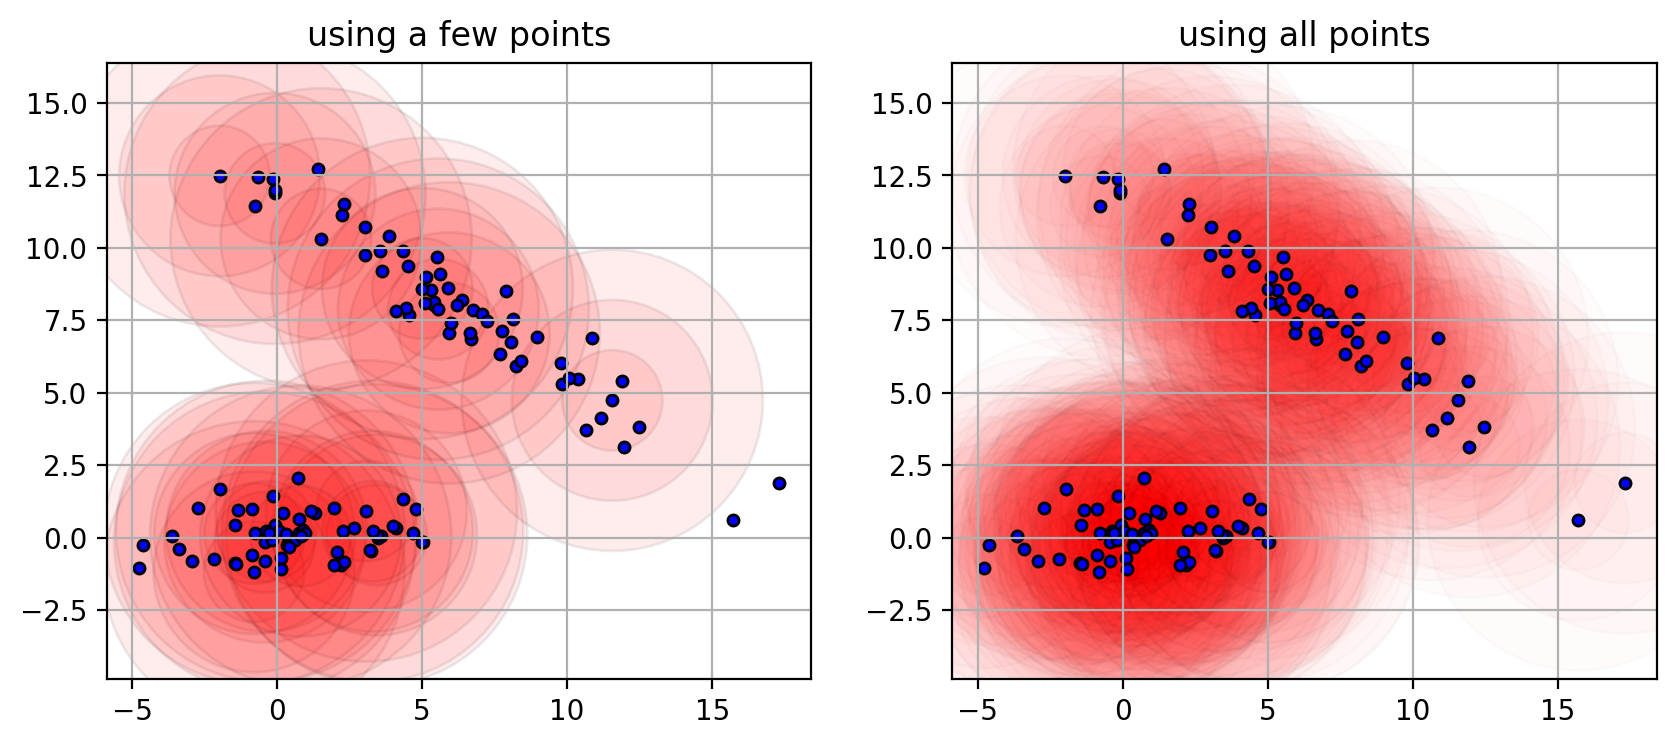

In [8]:
fig

# Kernel density estimator
- This is called a *kernel density estimator*
  - the *kernel* is the small Gaussian.

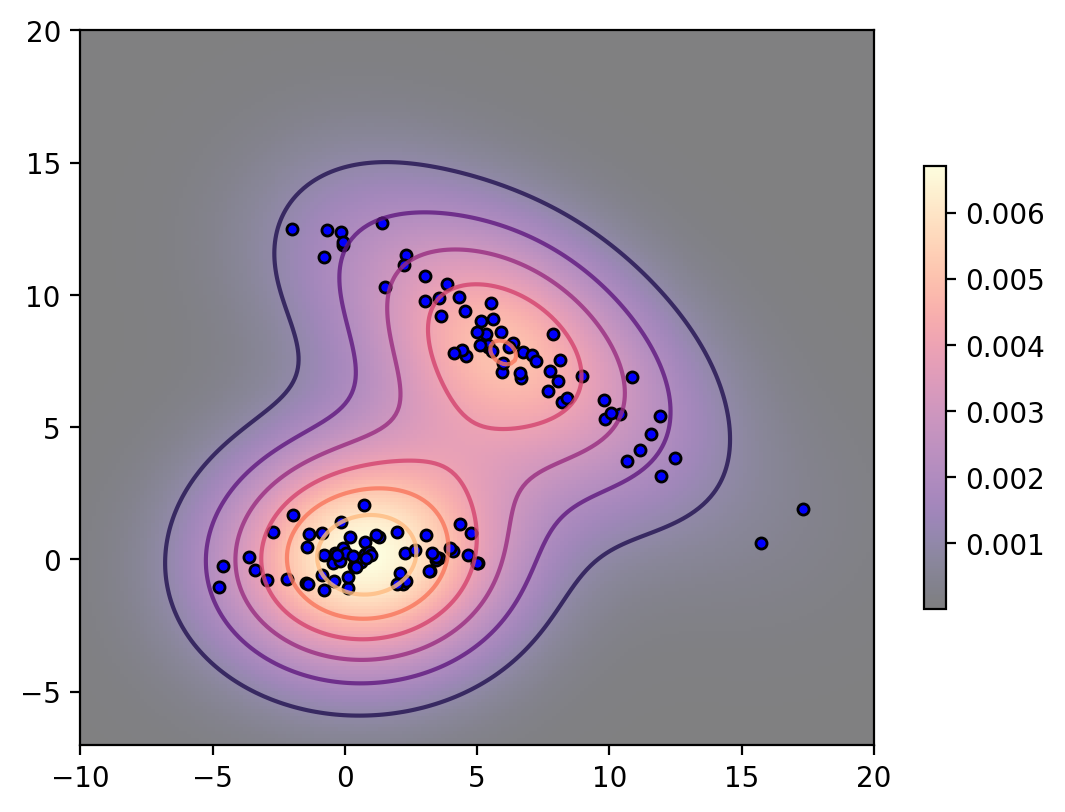

In [9]:
kde = neighbors.KernelDensity(bandwidth=3.0).fit(X)
plot_scores(kde, axbox, 'magma')
plt.scatter(X[:,0], X[:,1], c='b', s=ssize, edgecolors='k');

# Clustering using KDE
- The modes of the KDE can be considered the cluster centers.
  - A mode is a local maximum of the probability density.
  - The number of clusters is selected automatically according to the data.

- *How to find the cluster centers?*
  - mode: $\boldsymbol{\mu} = \mathop{\mathrm{argmax}}_x p(\mathbf{x})$
  - select a point, and run gradient ascent on $p(\mathbf{x})$.
    - $\hat{\boldsymbol{\mu}} \leftarrow \hat{\boldsymbol{\mu}} + \eta \frac{d}{d\mathbf{x}} p(\mathbf{x})$
  - using a clever choice of $\eta$, we get an algorithm that is guaranteed to converge called the "Mean-shift algorthm".

# Mean-shift algorithm
- **Idea:** iteratively shift towards the largest concentration of points.
  - start from an initial point $\mathbf{x}$ (e.g., one of the data points).
  - repeat until $\mathbf{x}$ is unchanged:
    1) find the nearest neighbors to $\mathbf{x}$ within some radius (bandwidth)
      - according to the Gaussian kernels.
    2) set $\mathbf{x}$ to be the mean of the neighbor points.

In [10]:
X = Xfull
x0 = X[3,:]-array([-2,0])    

efigs = []
for i in range(8):
    if i % 2 == 0:
        efigs.append(plt.figure(figsize=(10,4)))

    # need to use the function version which can set the number of iterations
    cc,cl = cluster.mean_shift(X, bandwidth=3, max_iter=0, seeds=[x0])

    plt.subplot(1,2,i%2+1)
    plt.scatter(X[:,0], X[:,1], c='b', edgecolors='k', s=ssize)
    plt.plot(x0[0],x0[1], 'ro', label='old x')
    circ = plt.Circle(x0, radius=3, color='r', alpha=0.2, label='neighborhood')
    plt.gca().add_patch(circ)
    plt.plot(cc[0,0],cc[0,1], 'co', label='new x')
    if (linalg.norm(x0-cc[0,:])>0.1):
        plt.arrow(x0[0], x0[1], cc[0,0]-x0[0], cc[0,1]-x0[1], 
                  width=0.1, length_includes_head=True, head_width=0.4, color='r')
    plt.axis('equal'); plt.grid(True)
    plt.title('iteration ' + str(i))
    if i==0:
        plt.legend(loc=0, fontsize=9)
    
    x0 = cc[0,:]
    
    if i%2 == 1:
        plt.close()

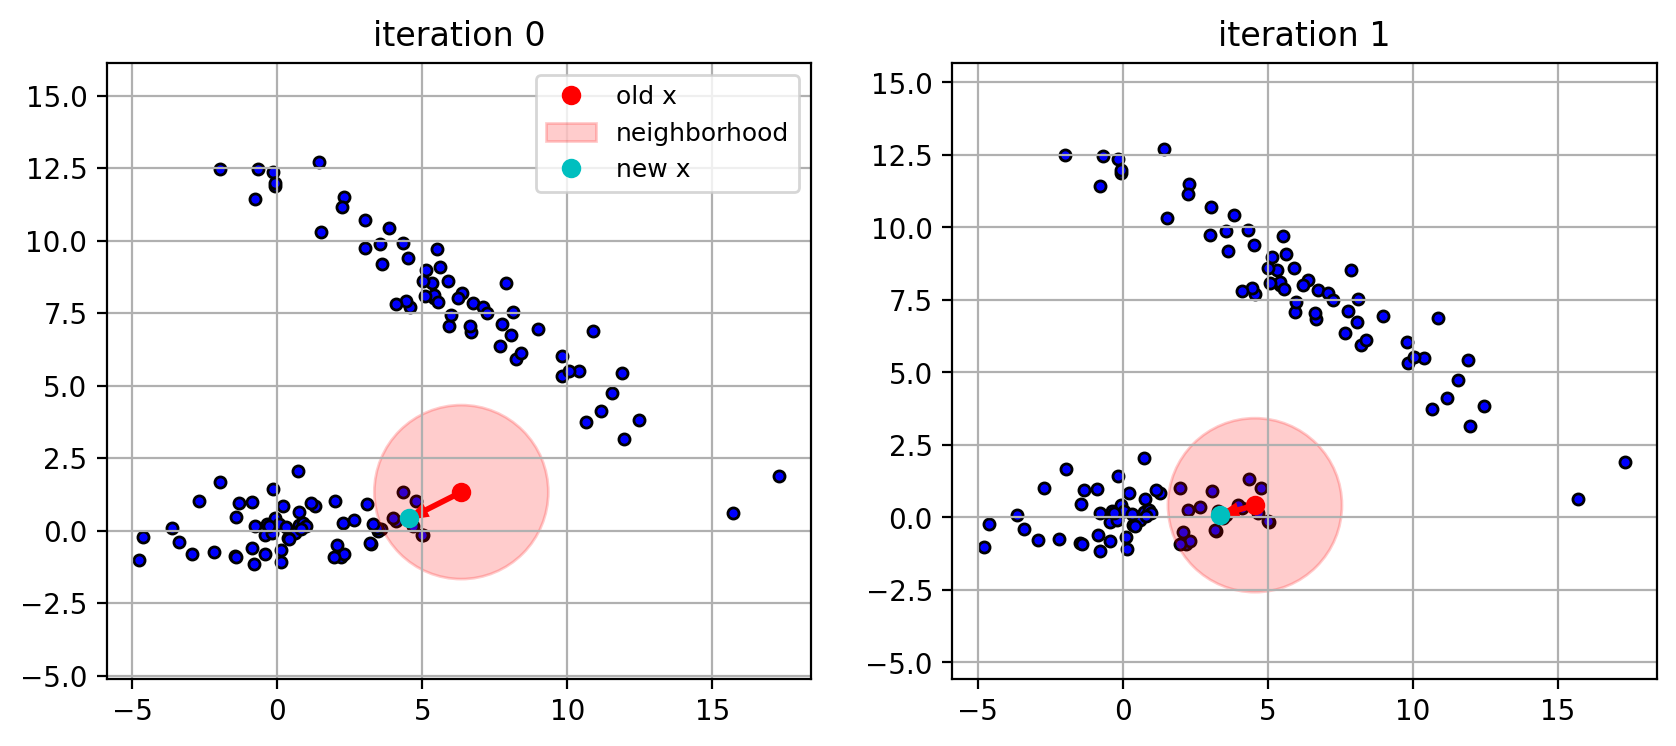

In [11]:
efigs[0]

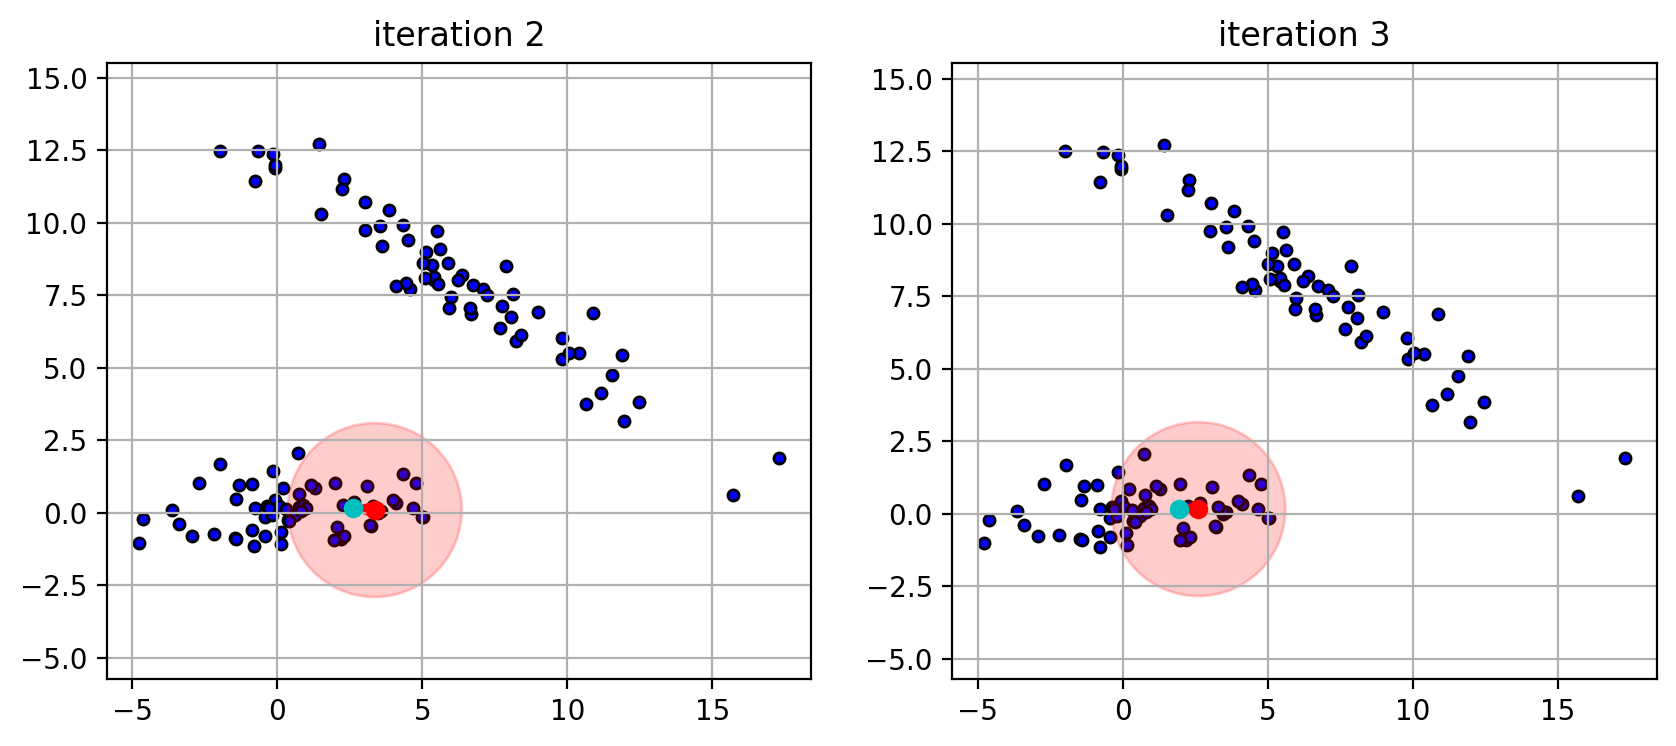

In [12]:
efigs[1]

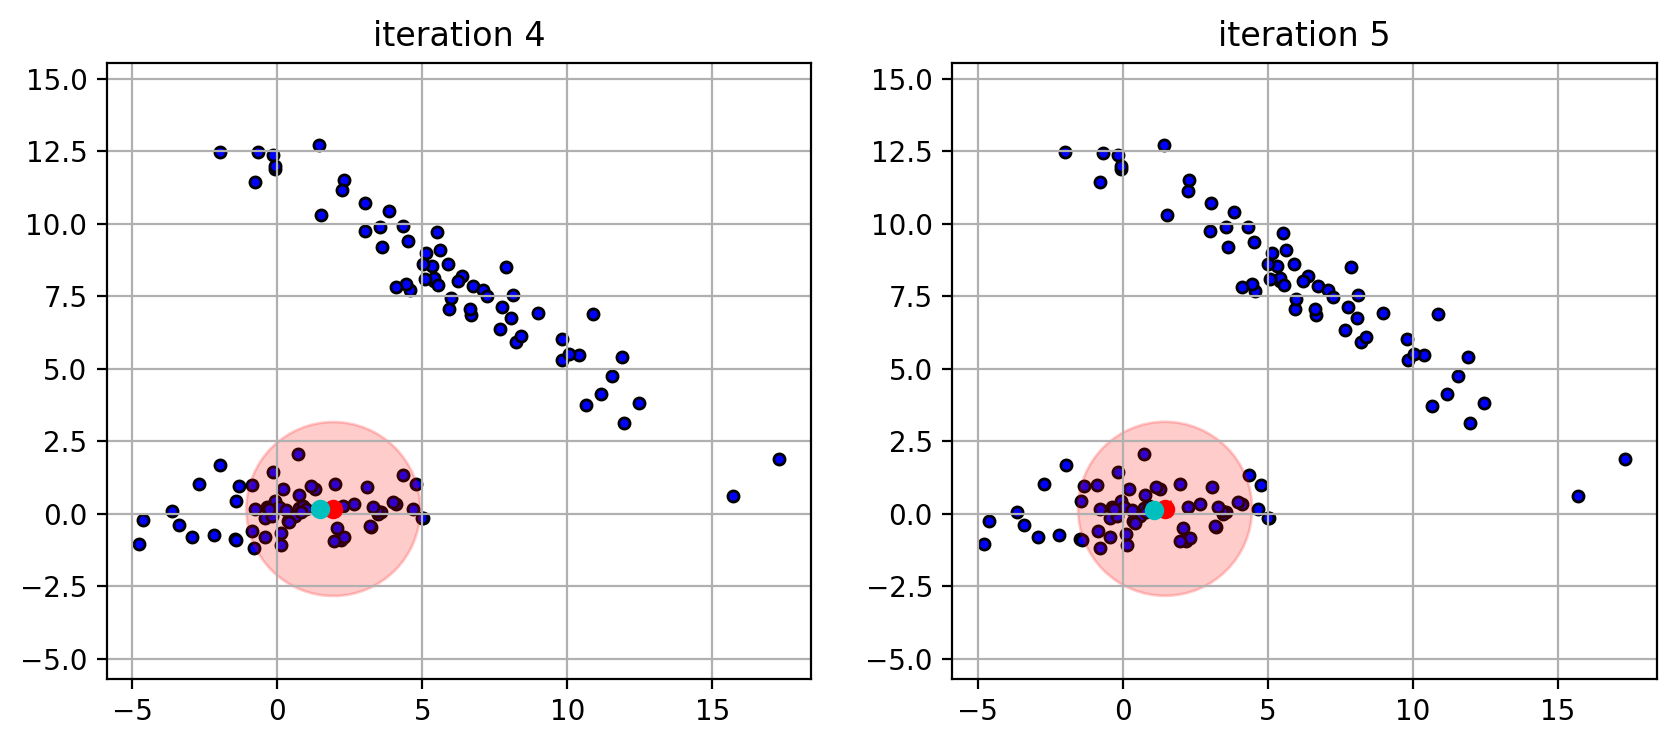

In [13]:
efigs[2]

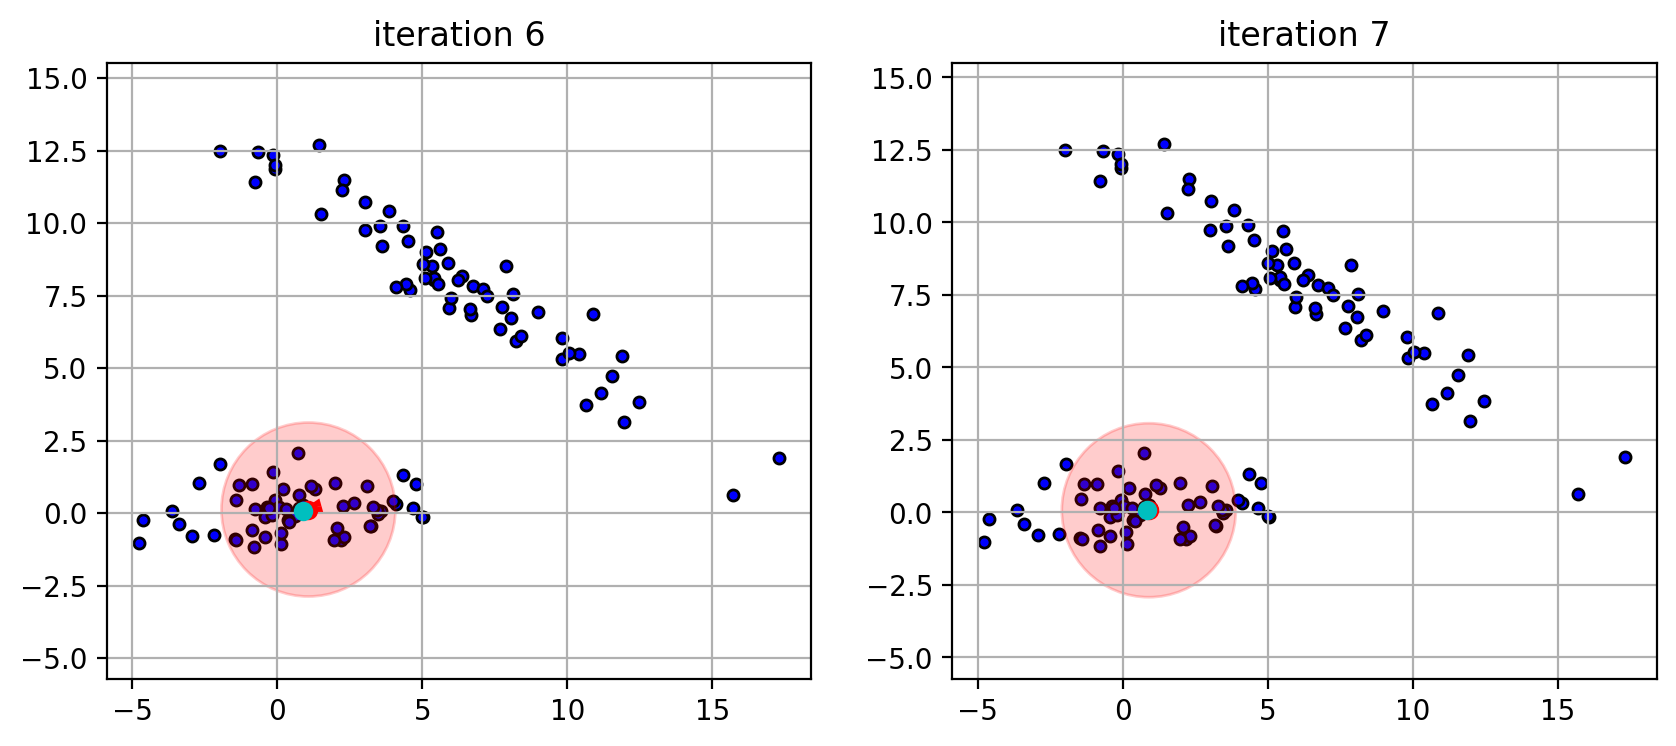

In [14]:
efigs[3]

# Getting the clusters
- Run the mean-shift algorithm for many initial points $\{\mathbf{x}_i\}$.
  - the set of converged points contain the cluster centers.
    - need to remove the duplicate centers.
  - data points that converge to the same center belong to the same cluster.

In [15]:
xpath = []
# use each point as starting point
for x0 in Xfull:
    tmp = [x0]
    for it in range(20):
        # need to use the function version which can set the number of iterations
        cc,cl = cluster.mean_shift(Xfull, bandwidth=5, max_iter=0, seeds=[x0])
        tmp.append(cc[0])
        x0 = cc[0]
    xpath.append(array(tmp))
xpath = array(xpath)


In [16]:
pfig = plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c='k', edgecolors='k', s=ssize)
for xp in xpath:
    plt.plot(xp[:,0], xp[:,1], '.:')
plt.scatter(xpath[:,-1,0], xpath[:,-1,1], s=250, marker='*', c='y', edgecolors='k', zorder=3)
plt.axis('equal'); plt.grid(True)
plt.close()

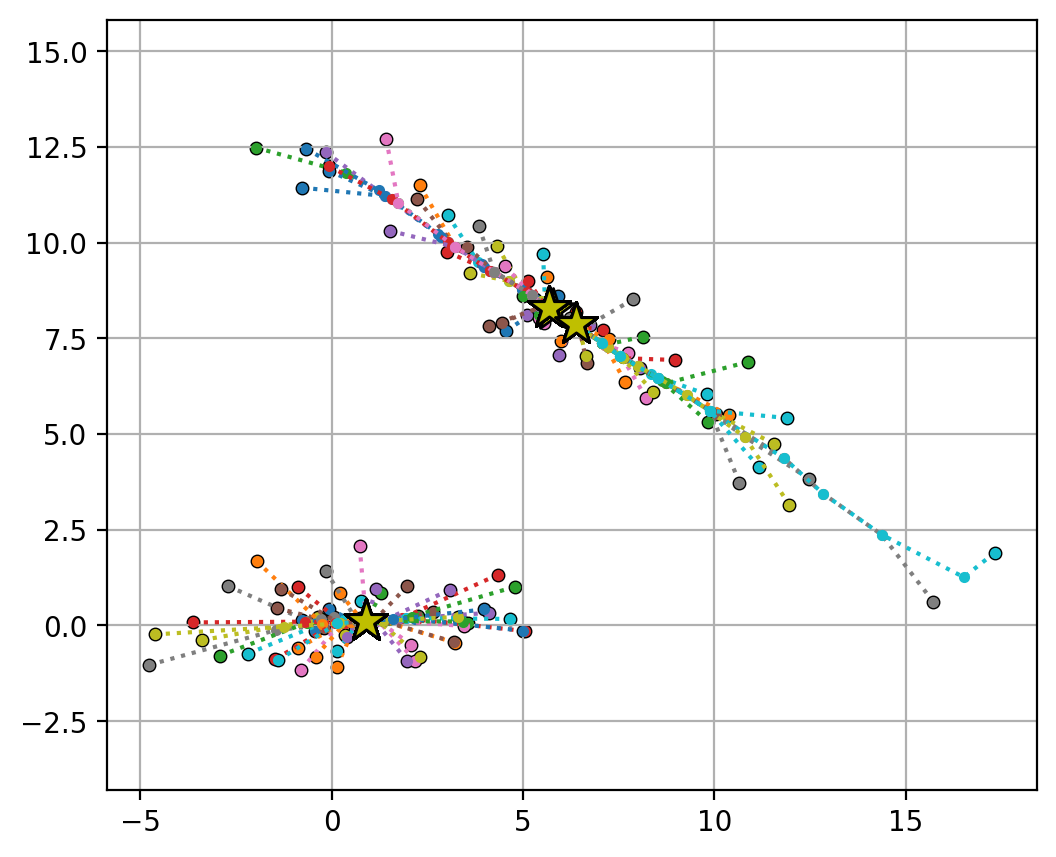

In [17]:
pfig

(2,)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


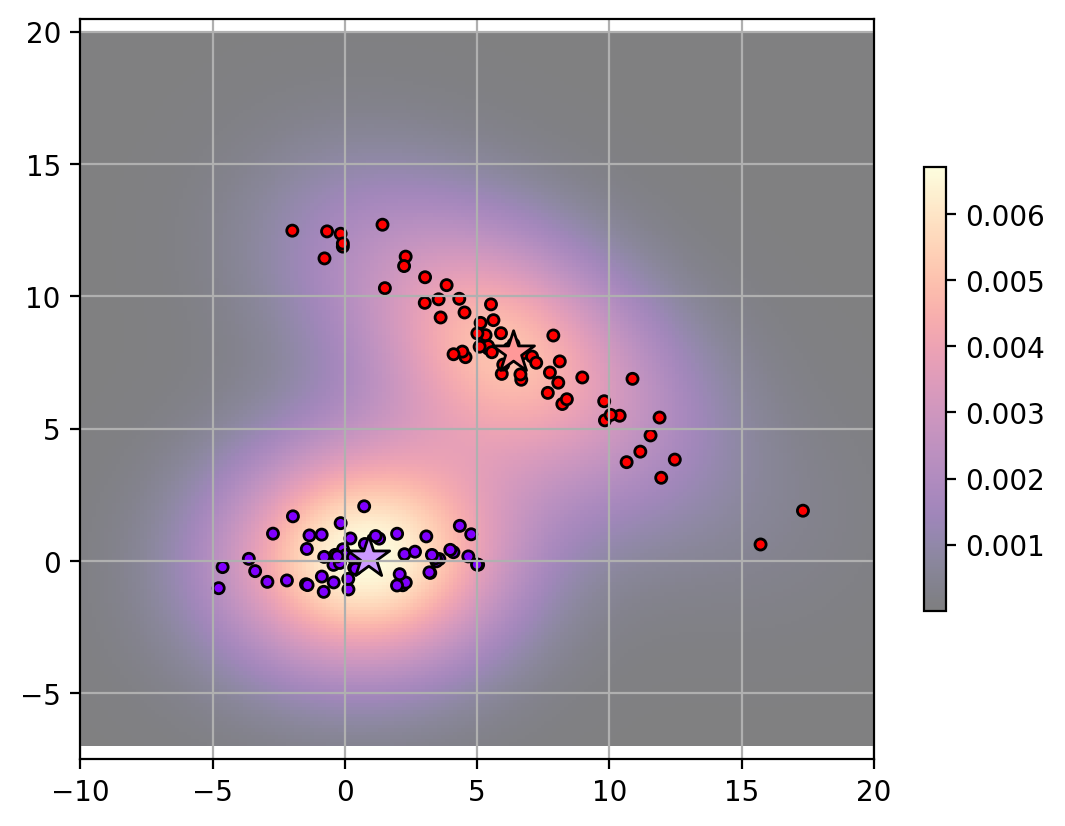

In [18]:
# bin_seeding=True -- coarsely uses data points as initial points
# different initializations can run in parallel (`n_jobs`)
ms = cluster.MeanShift(bandwidth=5, bin_seeding=True, n_jobs=-1)
Y = ms.fit_predict(X)

cc = ms.cluster_centers_  # cluster centers

plot_scores(kde, axbox, 'magma', showcontour=False)
plot_clusters(ms, axbox, X, Y, rbow, rbow2)

- Cluster partitions
  - assign point based on convergence to same cluster center

(2,)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


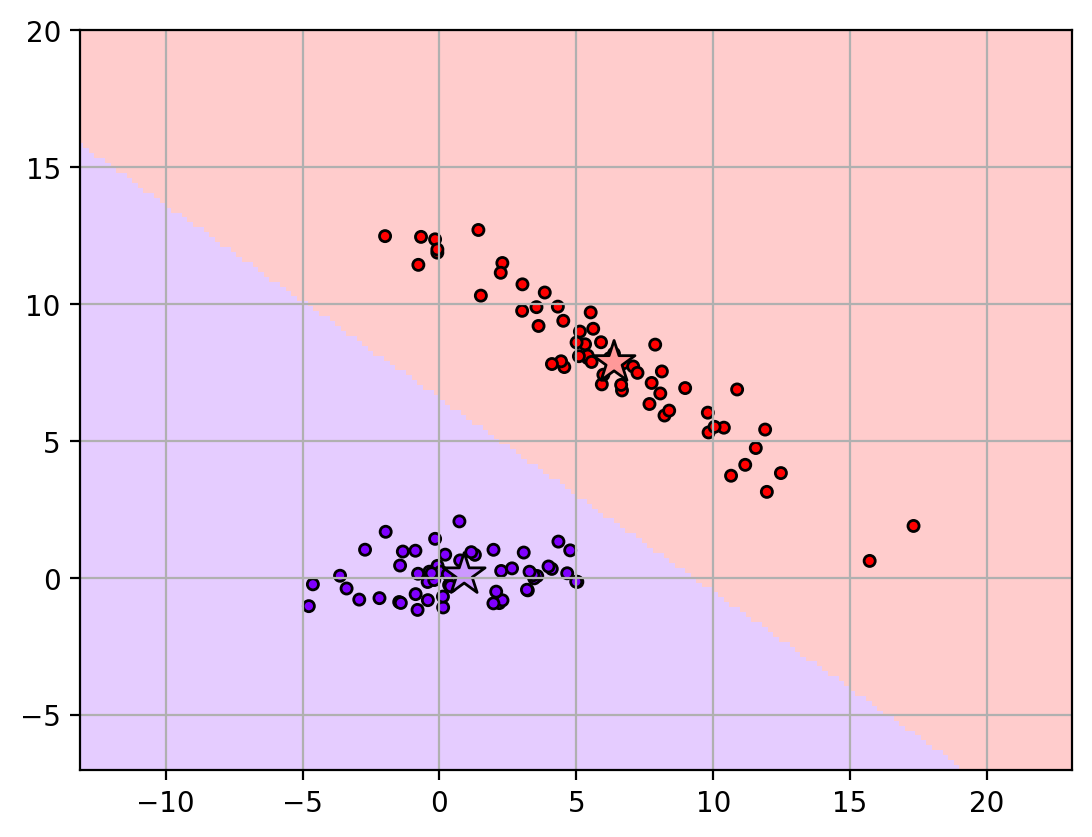

In [19]:
plot_clusters(ms, axbox, X, Y, rbow, rbow2, showregions=True)

# Number of clusters
- Number of clusters is implicitly controlled by the bandwidth (radius of the nearest-neighbors)
  - larger bandwidth creates less clusters
    - focuses on global large groups
  - smaller bandwidth creates more clusters
    - focuses on local groups.

In [20]:
msfig = plt.figure(figsize=(12,5))
for i,bw in enumerate([2, 3, 5, 10]):
    ms = cluster.MeanShift(bandwidth=bw, bin_seeding=True)
    Y = ms.fit_predict(X)

    kde = neighbors.KernelDensity(bandwidth=bw).fit(X)
    
    plt.subplot(2,4,i+1)
    plot_scores(kde, axbox, 'magma', showcontour=True, showlabels=False)
    plt.scatter(X[:,0], X[:,1], c='b', s=ssize, edgecolors='k')
    plt.title('bandwidth={}'.format(bw))
    plt.xticks([])
    plt.yticks([])
    plt.subplot(2,4,i+5)
    plot_clusters(ms, axbox, X, Y, rbow, rbow2)
    plt.title('{} clusters'.format(len(ms.cluster_centers_)))
    plt.xticks([])
    plt.yticks([])
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


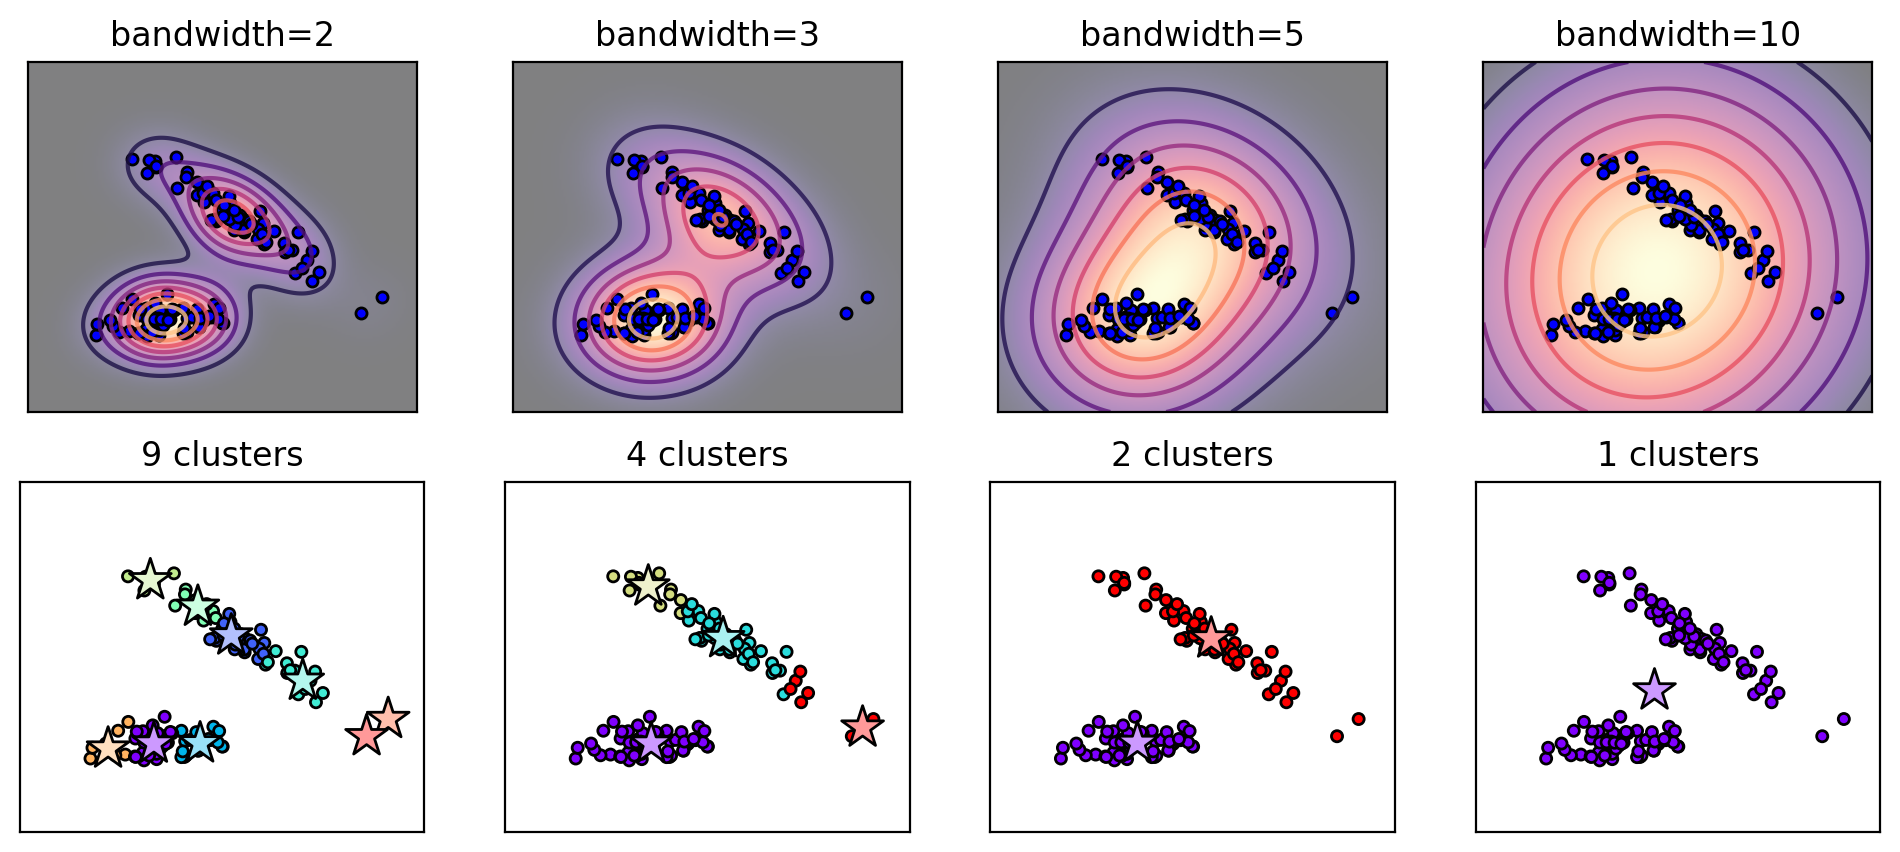

In [21]:
msfig

- Cluster partitions: assign points based on convergence to same cluster center.

In [22]:
msfig = plt.figure(figsize=(8,6))
for i,bw in enumerate([2, 3, 5, 10]):
    ms = cluster.MeanShift(bandwidth=bw, bin_seeding=True)
    Y = ms.fit_predict(X)

    plt.subplot(2,2,i+1)
    plot_clusters(ms, axbox, X, Y, rbow, rbow2, showregions=True)
    plt.title('bandwidth={}; {} clusters'.format(bw,len(ms.cluster_centers_)))
plt.tight_layout()
plt.close()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


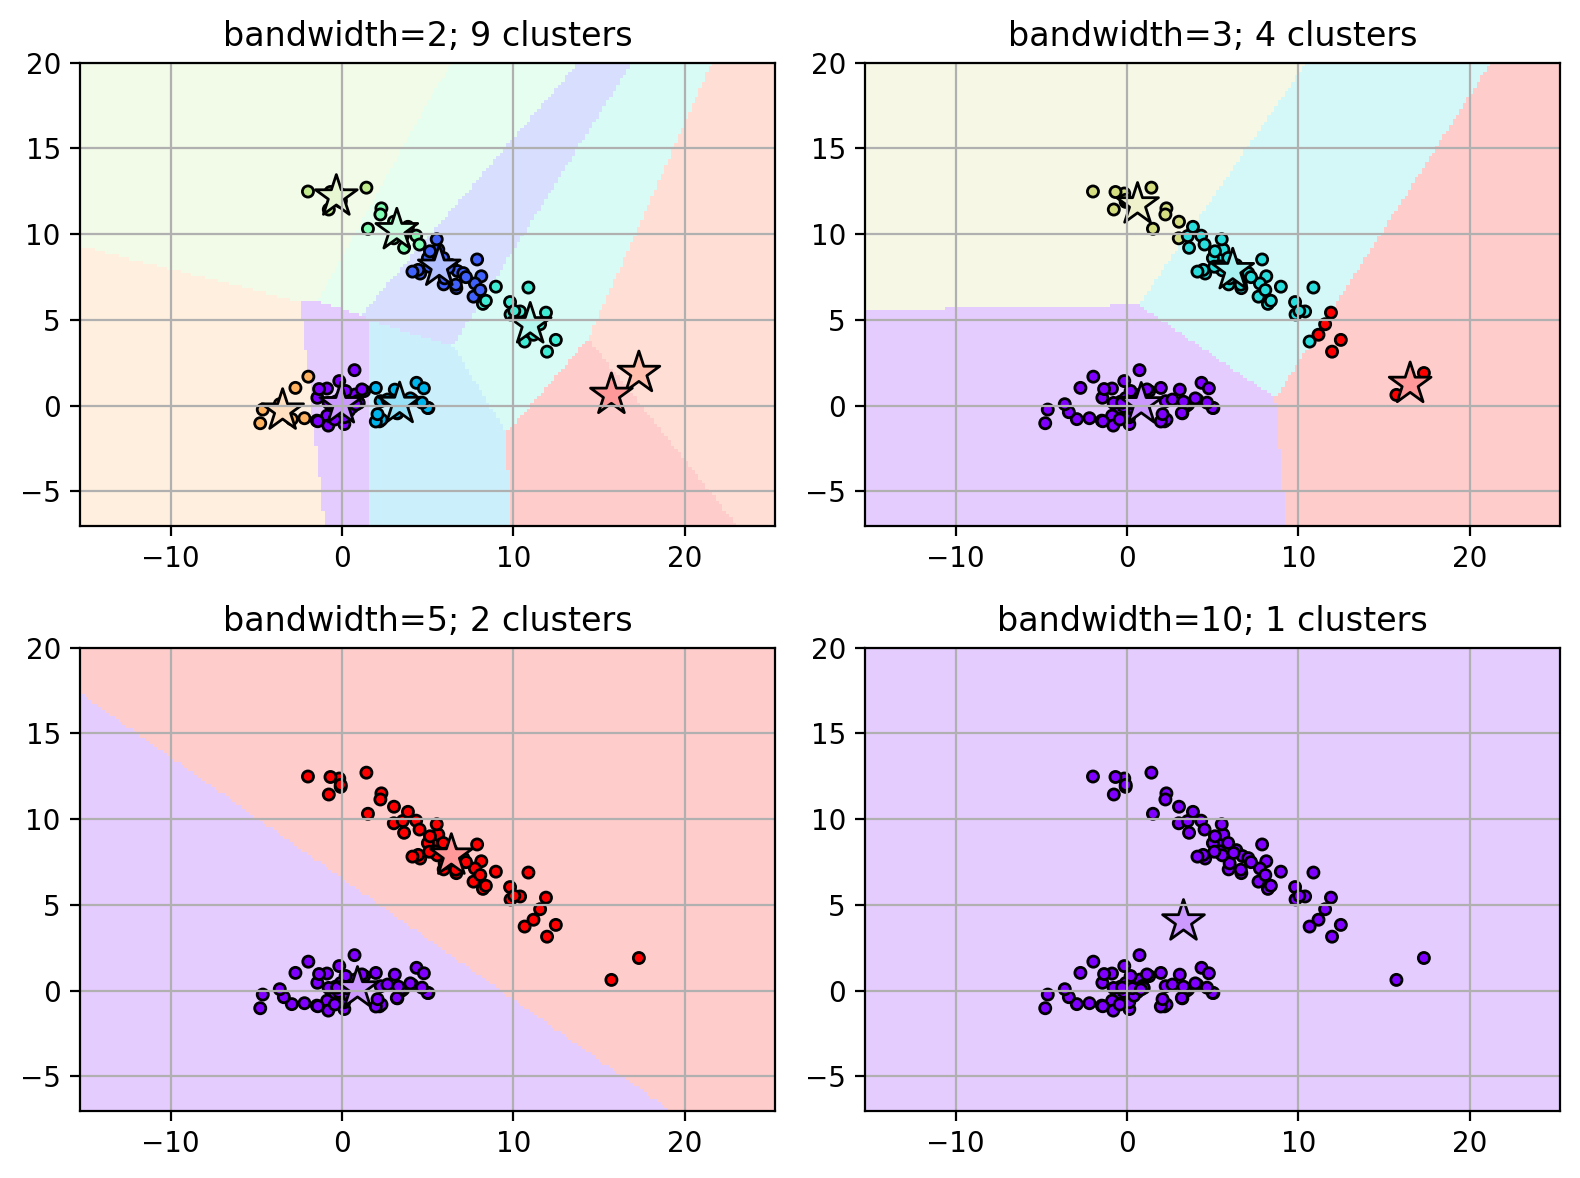

In [23]:
msfig

# Non-compact clusters
- K-means, GMM, and Mean-Shift assume that all clusters are compact.
  - i.e., circles or ellipses
- What about clusters of other shapes?
  - e.g., clusters not defined by compact distance to a "center"

In [24]:
random.seed(200)
X1 = 0.2*random.normal(0,1,[50, 2])
X1[:,1] *= 8
X1[:,0] += 0.3*power(X1[:,1],2) - 5

X2 = 0.4*random.normal(0,1,[50,2])-array([2,0])
X3 = 0.4*random.normal(0,1,[50,2])+array([2,0])

X4 = 0.2*random.normal(0,1,[50, 2])
X4[:,1] *= 8
X4[:,0] -= 0.3*power(X4[:,1], 2) - 5

Xtie = r_[X1,X2,X3,X4]
axboxtie = [-6, 6, -6, 6]

X = Xtie
axbox = axboxtie

km = cluster.KMeans(n_clusters=4, random_state=1234)
km.fit(X)

gmmf = mixture.GaussianMixture(n_components=4, covariance_type='full', random_state=4487, n_init=10)
gmmf.fit(X)

ms = cluster.MeanShift(bandwidth=2, bin_seeding=True)
ms.fit(X)

tiefig = plt.figure(figsize=(10,3))
plt.subplot(1,4,1)
plt.scatter(X[:,0], X[:,1], c='b', edgecolors='k', s=ssize)
plt.axis(axbox)
plt.grid(True)
plt.title('data')

for i,m in enumerate([km, gmmf, ms]):
    plt.subplot(1,4,i+2)
    Y = m.predict(X)
    plot_clusters(m, axbox, X, Y, rbow, rbow2)
    plt.grid(True)
    plt.title(m.__class__.__name__)
plt.tight_layout()
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


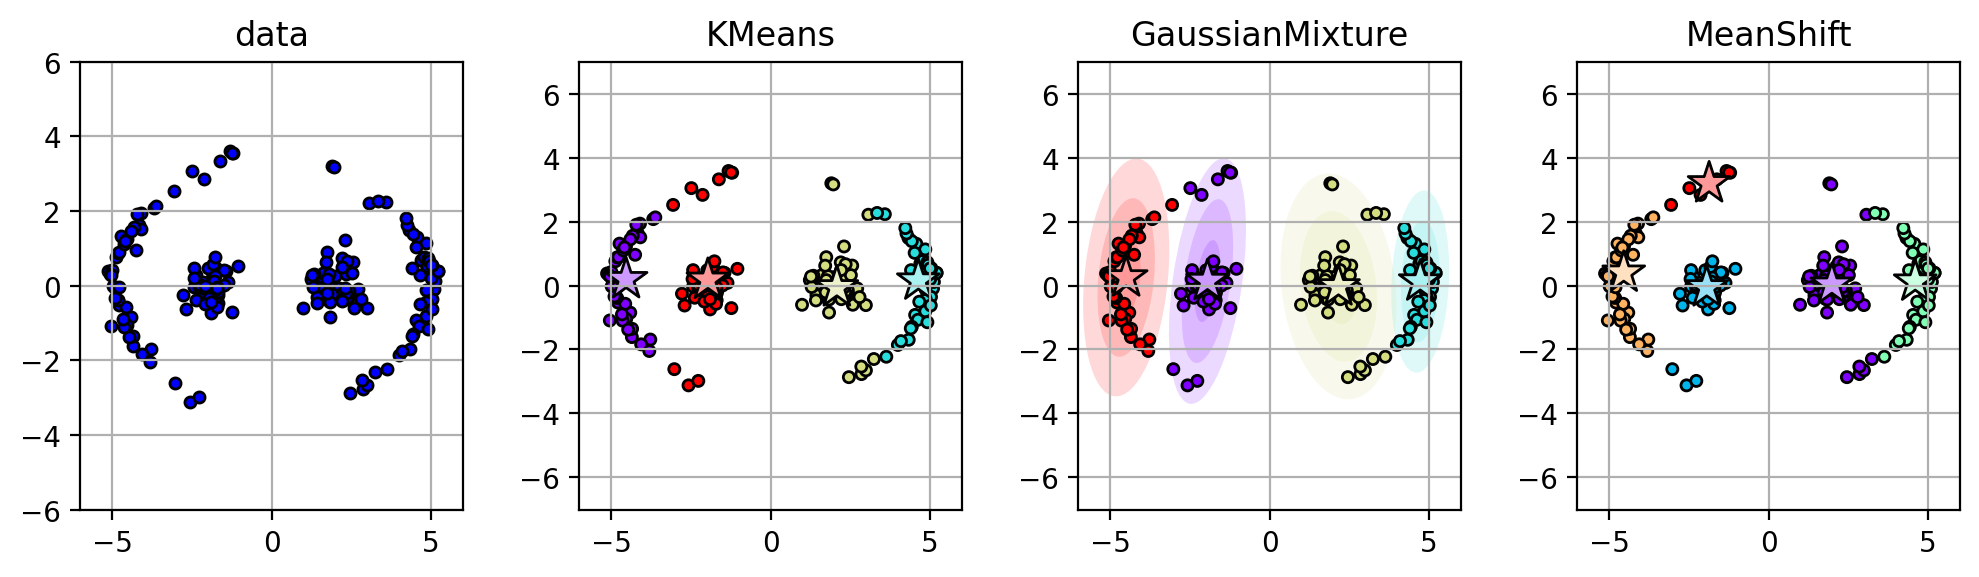

In [25]:
tiefig

In [26]:
Xcirc,Y = datasets.make_circles(n_samples=300, noise=0.05, factor=0.2)
axboxcirc = [-1.5, 1.5, -1.5, 1.5]

X = Xcirc
axbox = axboxcirc

km = cluster.KMeans(n_clusters=2, random_state=1234)
km.fit(X)

gmmf = mixture.GaussianMixture(n_components=2, covariance_type='full', random_state=4487, n_init=10)
gmmf.fit(X)

ms = cluster.MeanShift(bandwidth=0.5, bin_seeding=True)
ms.fit(X)

circfig = plt.figure(figsize=(8,6))
plt.subplot(2,2,1)
plt.scatter(X[:,0], X[:,1], c='b', edgecolors='k', s=ssize)
plt.grid(True); plt.axis(axbox)
plt.title('data')

for i,m in enumerate([km, gmmf, ms]):
    plt.subplot(2,2,i+2)
    Y = m.predict(X)
    plot_clusters(m, axbox, X, Y, rbow, rbow2)
    plt.grid(True)
    plt.title(m.__class__.__name__)
plt.tight_layout()
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


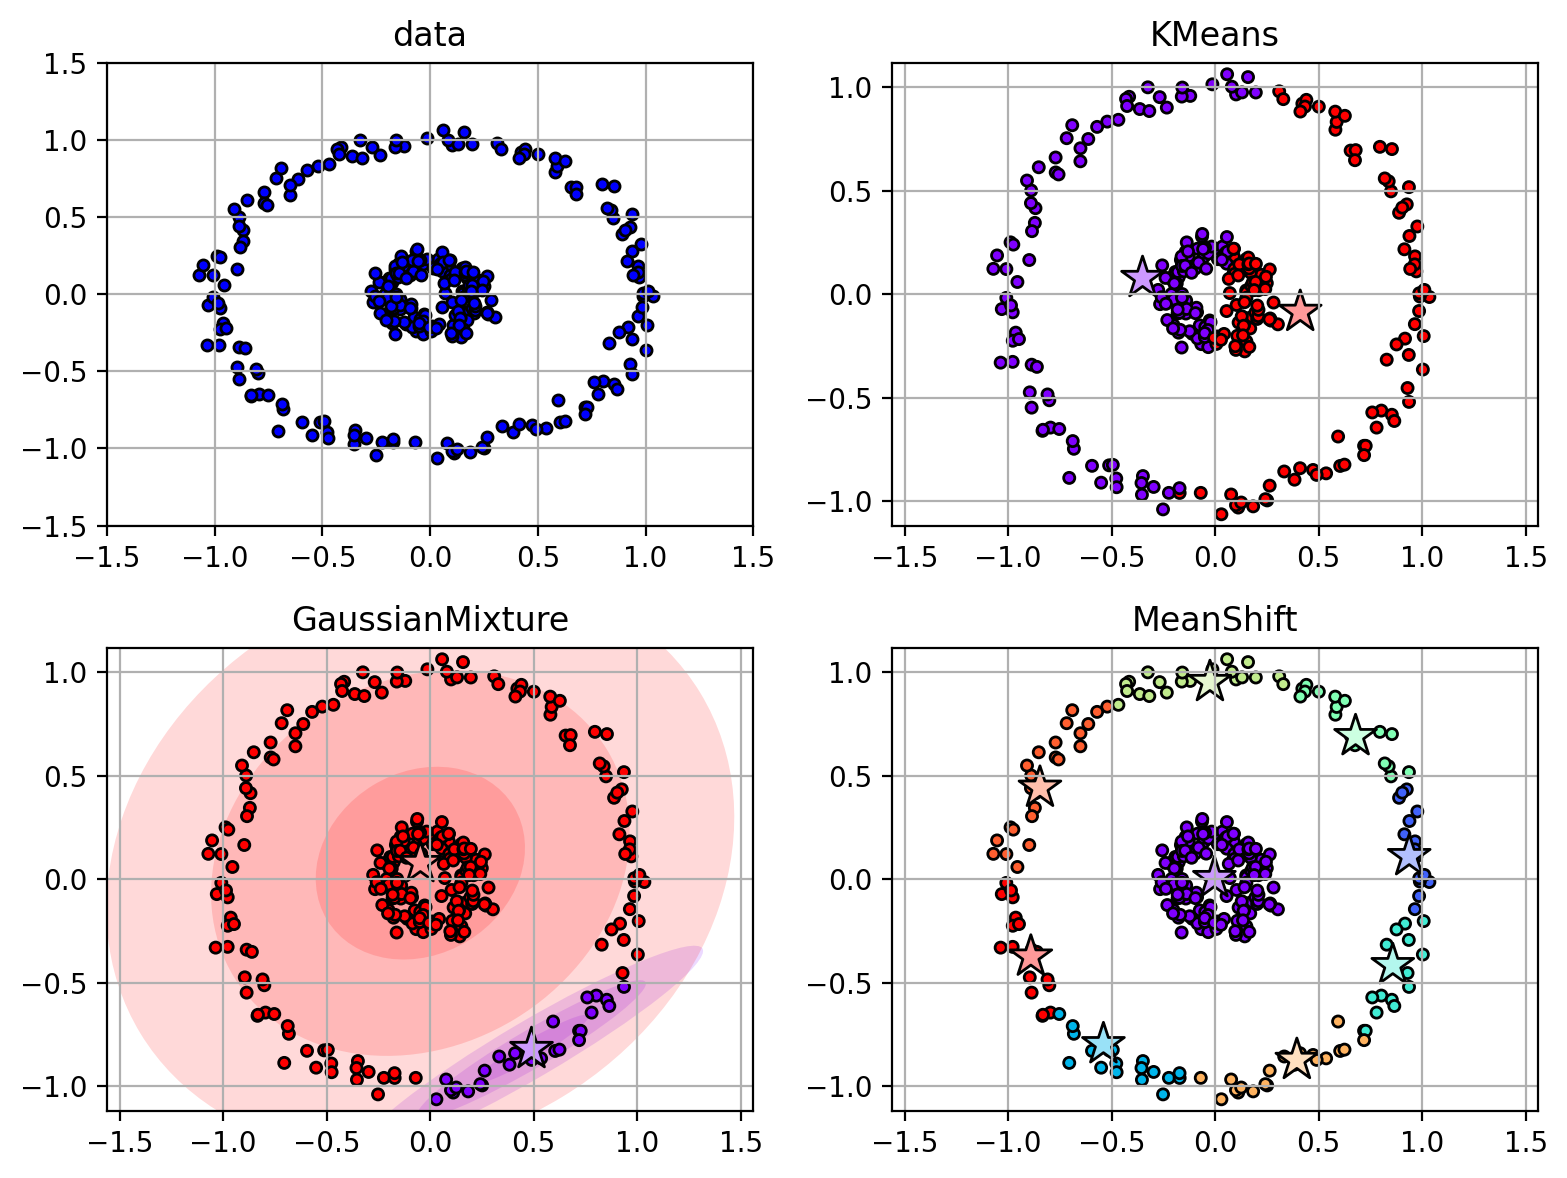

In [27]:
circfig

# Spectral Clustering
- Estimate clusters using pair-wise affinity between points.
- Affinity (similarity) between points 
  - kernel function: $k(\mathbf{x}_i,\mathbf{x}_j)$ -- RBF kernel
  - number of nearest neighbors within a radius (bandwidth)

In [28]:
X = Xtie
axbox = axboxtie

sc = cluster.SpectralClustering(n_clusters=4, affinity='rbf', gamma=1.0, assign_labels='discretize', n_jobs=-1)
Y = sc.fit_predict(X)  # cluster and also return the labels Y

cl = sc.labels_  # labels for each X
ii = random.permutation(len(cl))

afig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.scatter(X[:,0], X[:,1], c='b', edgecolors='k', s=ssize)
plt.title('Data'); plt.grid(True); plt.axis(axbox)

plt.subplot(1,2,2)
plt.imshow(sc.affinity_matrix_[ix_(ii,ii)], interpolation='nearest', cmap='jet')
plt.title('affinity matrix')
plt.xlabel('data point index'); plt.ylabel('data point index')
plt.close()

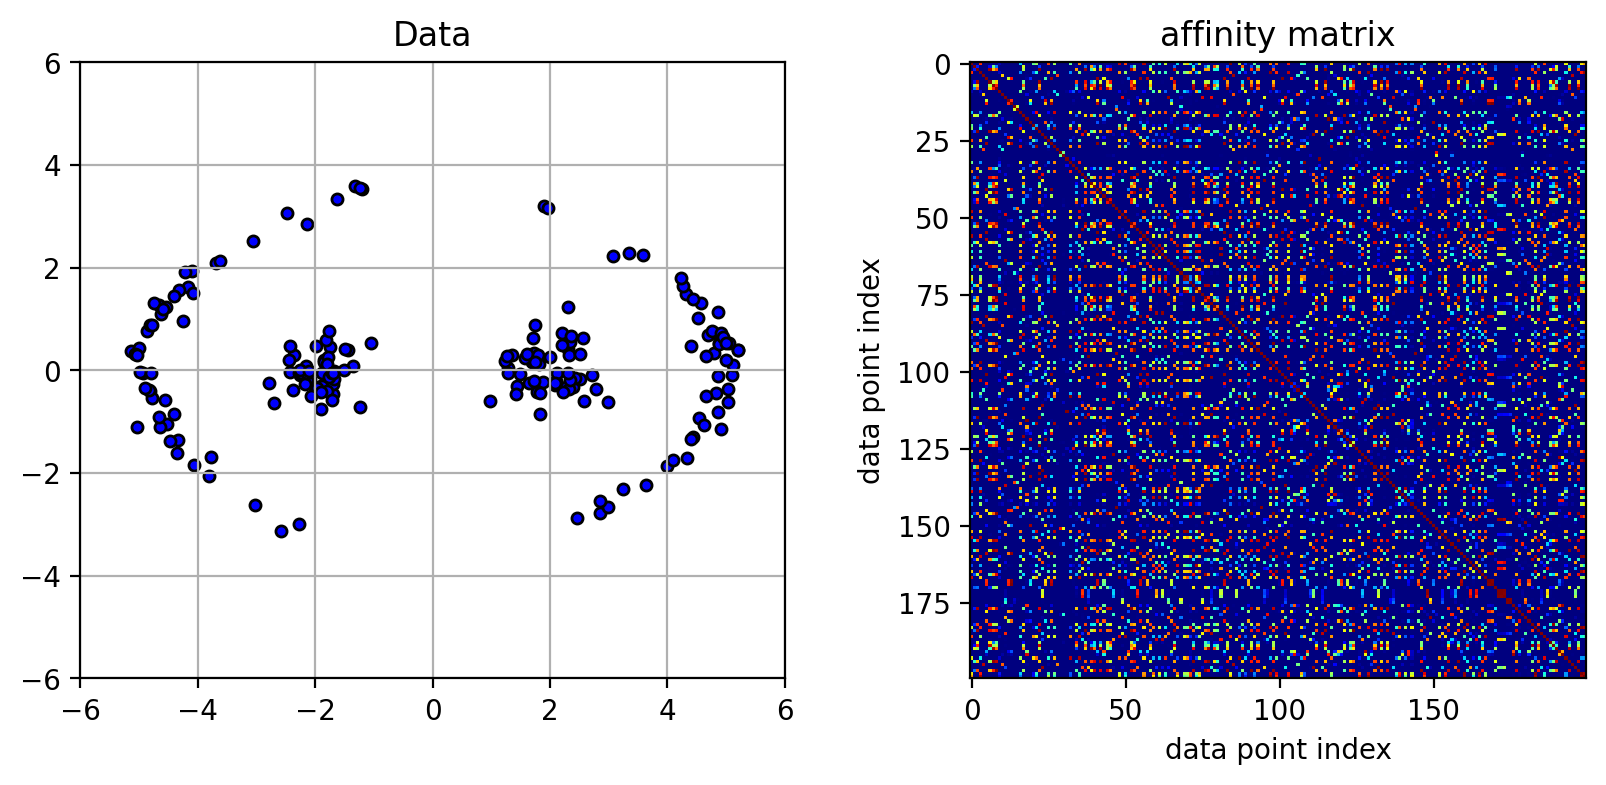

In [29]:
afig

# Spectral Clustering
- **Idea:** clustering with a graph formulation
  - each data point is a node in a graph
  - edge weight between two nodes is the affinity $k(\mathbf{x}_i,\mathbf{x}_j)$
    - (darker colors indicate stronger weights)

In [30]:
def plot_sc_graph(X, gamma, axbox):
    Xlen = X.shape[0]
    # calculate kernel
    K = metrics.pairwise.rbf_kernel(X, gamma=gamma)

    # graph figure
    for i in range(Xlen):
        for j in range(i+1,Xlen):
            if (K[i,j] > 0.01):
                plt.plot([X[i,0], X[j,0]], [X[i,1], X[j,1]], 
                         color=0.95*(1-K[i,j])*ones(3), zorder=K[i,j])
    # plot points
    plt.scatter(X[:,0], X[:,1], zorder=2, c='r', edgecolors='k', s=ssize)
    plt.axis(axbox); plt.grid(True)
    
    
X = Xtie[::2,:]
graphfig = plt.figure()
plot_sc_graph(X, 1.0, axbox)
plt.close()

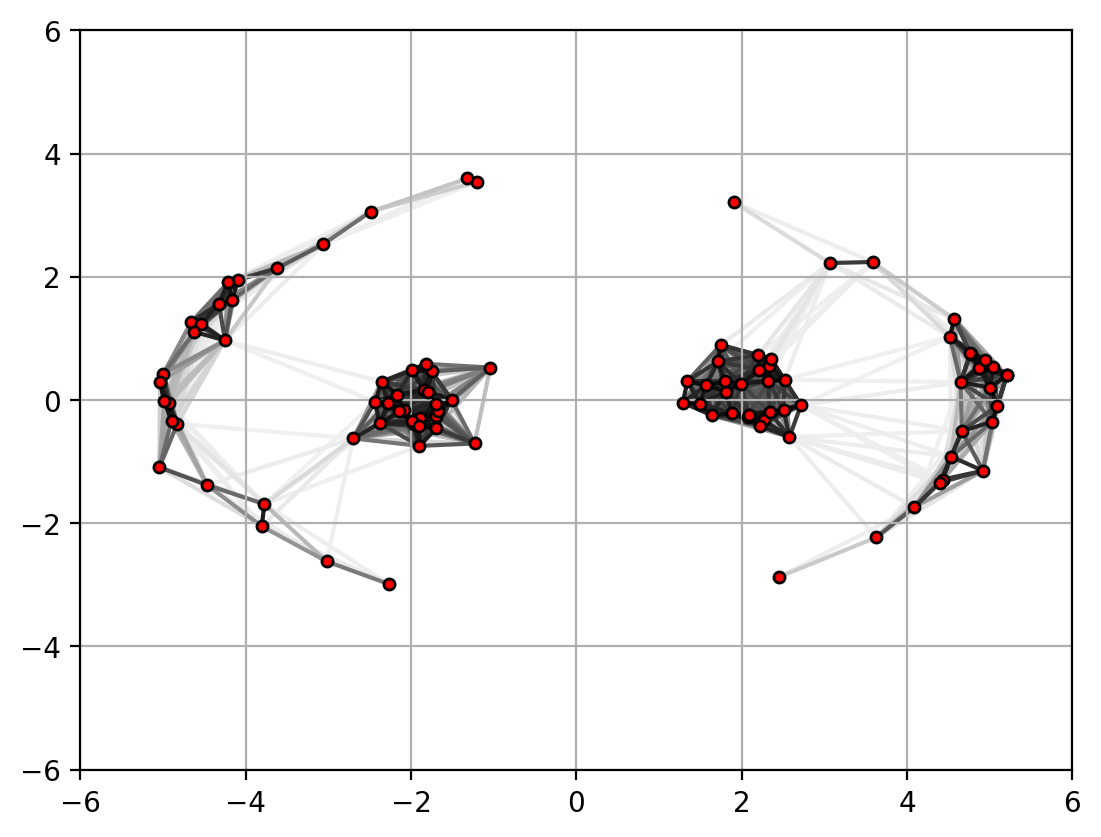

In [31]:
graphfig 

- **Goal:** cut the graph into clusters such that weights of cut edges is small compared to the total edge weight within each cluster.
  - find "blocks" of high affinity in the affinity matrix.


- Intuitively, consider a "mass-spring" system -- masses connected together with springs.
  - the graph nodes are masses, the edge weights are the spring stiffness.
  - if you hit the masses...
    - the masses that are tightly connected by stiff springs will move together in a low-frequency vibration mode.

- These low-frequency modes are found with the smallest non-zero eigenvectors of the graph Laplacian
- Graph Laplacian: $\mathbf{L} = \mathbf{D} - \mathbf{A}$
  - $\mathbf{A}$ is the adjacency (affinity) matrix.
  - $\mathbf{D}$ is the degree matrix.
    - diagonal matrix with entry $D_{ii} = \sum_j A_{i,j}$
- There are different ways to define the Laplacian, leading to different versions of Spectral Clustering
  - the one in sklearn is called "Normalized Cuts".

In [32]:
X = Xtie
axbox = axboxtie


In [33]:
# spectral clustering
# rbf affinity
sc = cluster.SpectralClustering(n_clusters=4, affinity='rbf',
                                gamma=1.0, assign_labels='discretize', n_jobs=-1)
Y = sc.fit_predict(X)

In [34]:
ii = argsort(Y)
scfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sc.affinity_matrix_[ix_(ii,ii)], interpolation='nearest', cmap='jet')
plt.title('sorted affinity matrix')

plt.subplot(1,2,2)
plot_clusters(sc, axbox, X, Y, rbow, rbow2)
plt.close()

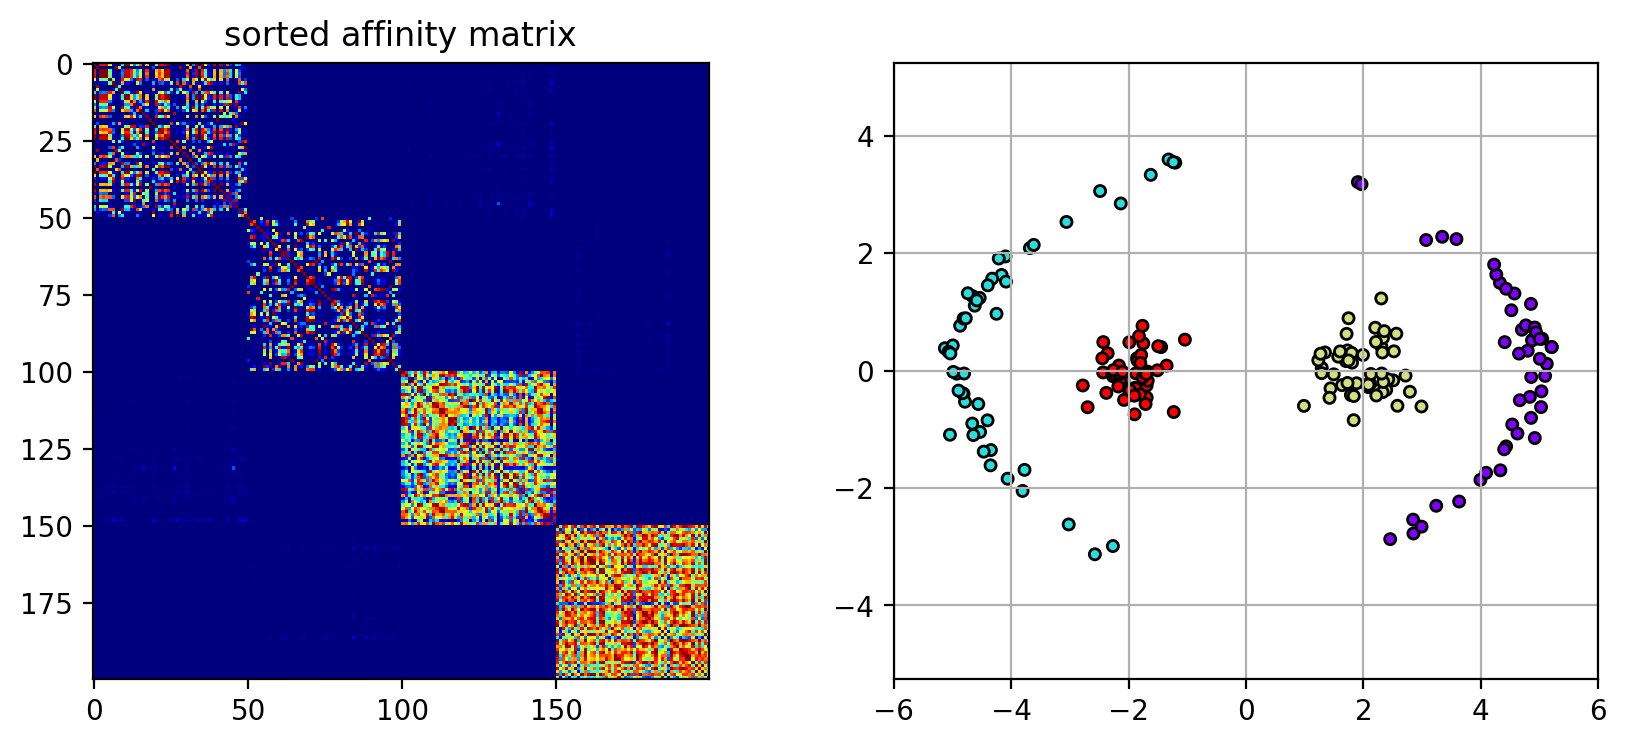

In [40]:
scfig

# Sensitivity to gamma
- gamma controls which structures are important
  - small gamma - far away points are still considered similar
  - large gamma - only close points are considered as similar

In [41]:
X = Xtie
axbox = axboxtie

scfig2 = plt.figure(figsize=(12,5))
for i,g in enumerate([1.0, 10.0, 20., 100]):
    sc = cluster.SpectralClustering(n_clusters=4, affinity='rbf', gamma=g,
                                assign_labels='discretize', n_jobs=-1)
    Y = sc.fit_predict(X)

    plt.subplot(2,4,i+1)
    ii = argsort(Y)
    plt.imshow(sc.affinity_matrix_[ix_(ii,ii)], interpolation='nearest', cmap='jet')
    plt.title('gamma=' + str(g))
    plt.xticks([]); plt.yticks([])
    plt.subplot(2,4,i+5)
    plot_clusters(sc, axbox, X, Y, rbow, rbow2)
    plt.xticks([]); plt.yticks([])
    
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


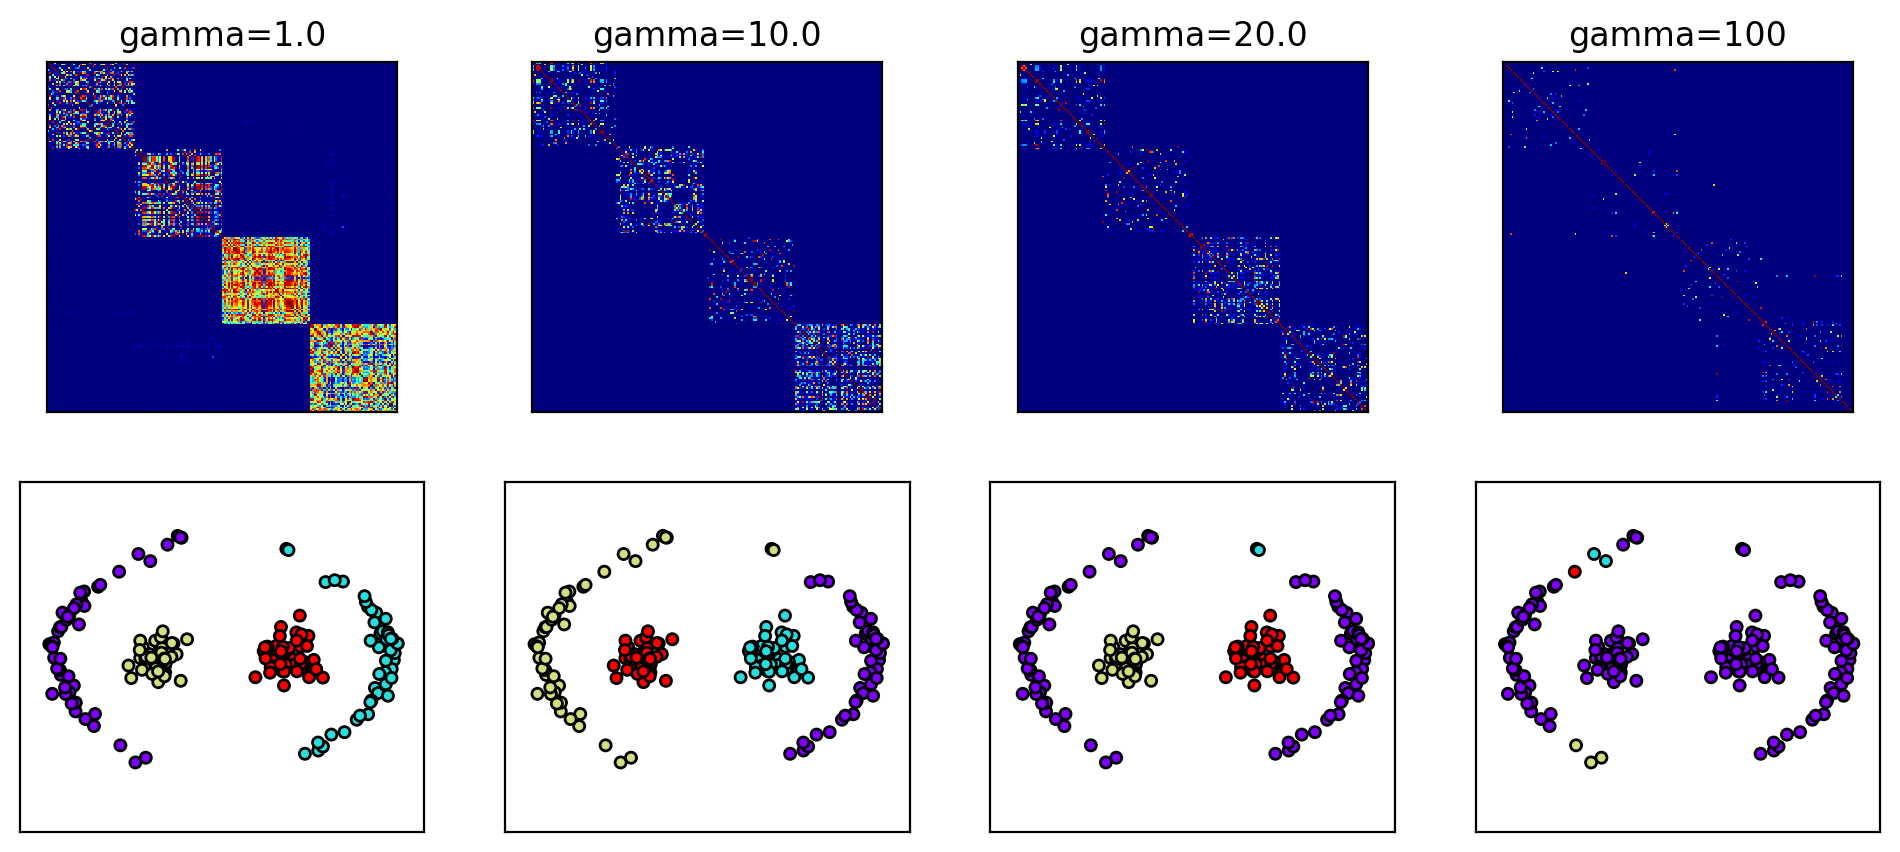

In [42]:
scfig2

# Another Example

In [43]:
X = Xcirc[::2,:]
axbox = axboxcirc
graphfig2 = plt.figure()
plot_sc_graph(X, 10.0, axbox)
plt.close()

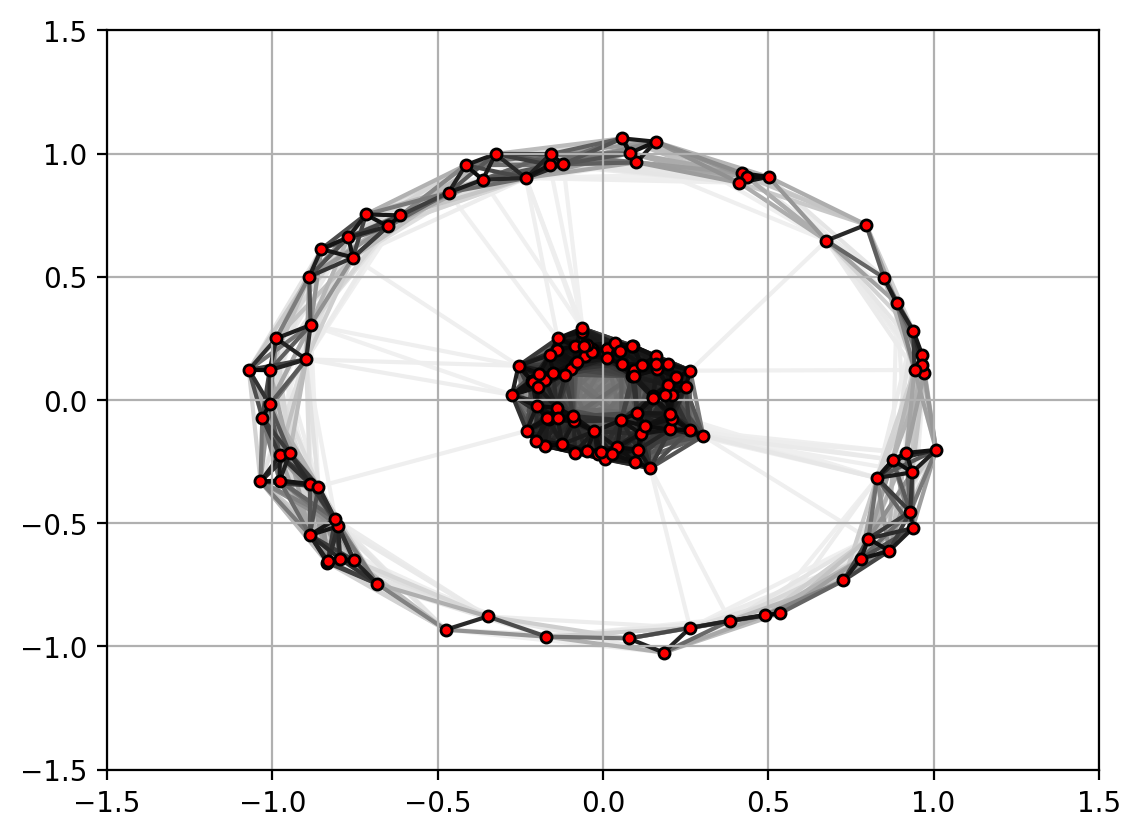

In [44]:
graphfig2

In [45]:
X = Xcirc
axbox = axboxcirc
sc = cluster.SpectralClustering(n_clusters=2, affinity='rbf',
                                gamma=10, assign_labels='discretize', n_jobs=-1)
Y = sc.fit_predict(X)

ii = argsort(Y)

scfig = plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(sc.affinity_matrix_[ix_(ii,ii)], interpolation='nearest', cmap='jet')
plt.title('sorted affinity matrix')

plt.subplot(1,2,2)
plot_clusters(sc, axbox, X, Y, rbow, rbow2)
plt.close()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


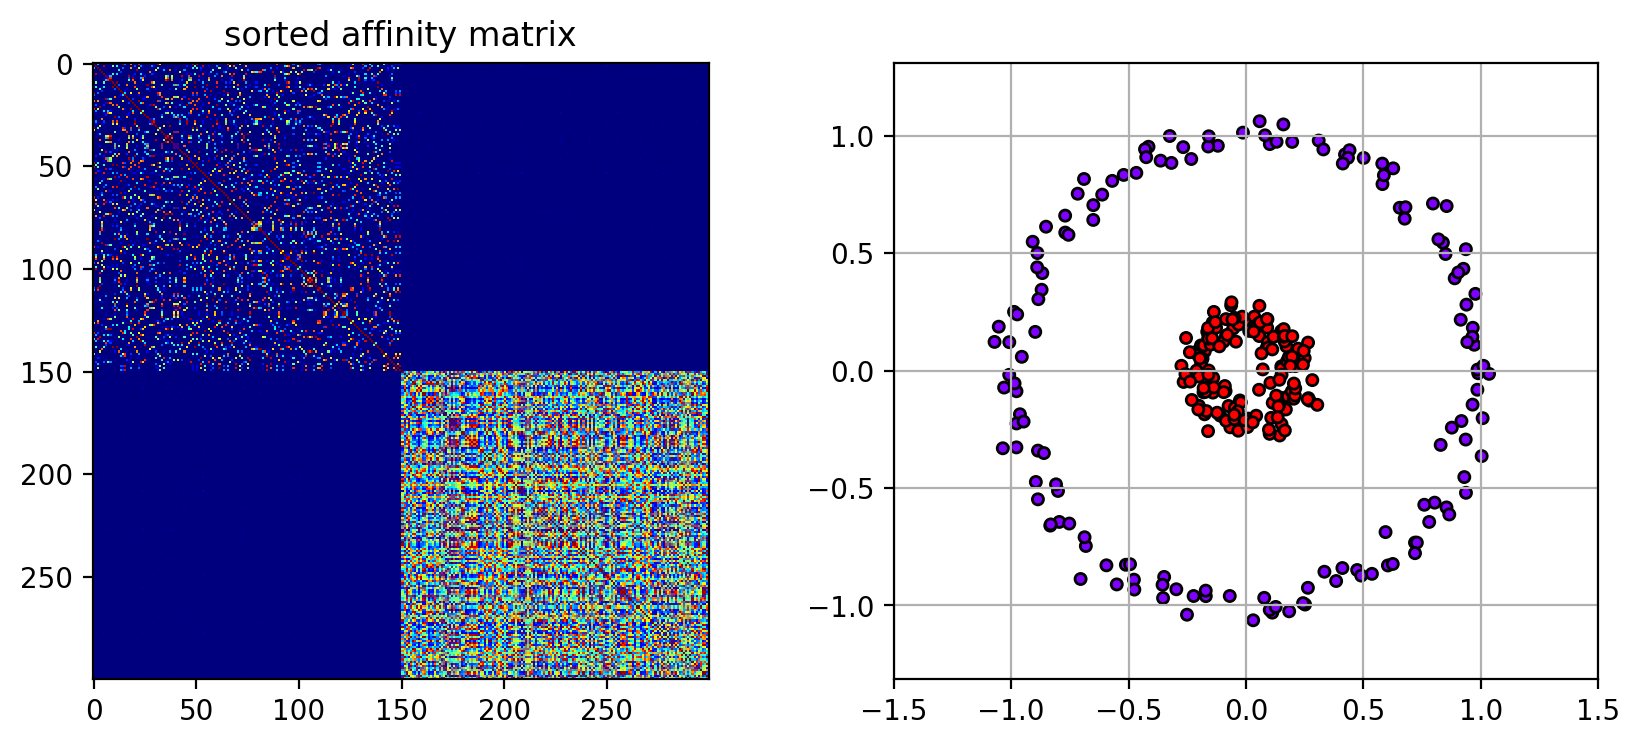

In [46]:
scfig

# Clustering Summary
- **Goal:** given set of input vectors $\{\mathbf{x}_i\}_{i=1}^n$, with $\mathbf{x}_i\in\mathbb{R}^d$, group similar $x_i$ together into clusters.
  - estimate a cluster center, which represents the data points in that cluster.
  - predict the cluster for a new data point.
  
<table style="font-size:9pt;">
<tr>
<th>Name</th>
<th>Cluster Shape</th>
<th>Principle</th>
<th>Advantages</th>
<th>Disadvantages</th>
</tr>
<tr>
<td>K-Means</td>
<td>circular</td>
<td>minimize distance to cluster center</td>
<td>- scalable (MiniBatchKMeans)</td>
<td>- sensitive to initialization; could get bad solutions due to local minima.<br>- need to choose K.</td>
</tr>
<tr>
<td>Gaussian Mixture Model</td>
<td>elliptical</td>
<td>maximum likelihood</td>
<td>- elliptical cluster shapes.</td>
<td>- sensitive to initialization; could get bad solutions due to local minima.<br>- need to choose K.</td>
</tr>
<tr>
<td>Bayesian GMM</td>
<td>elliptical</td>
<td>maximum marignal likelihood</td>
<td>- automatically selects K via concentration parameter.</td>
<td>- can be slow.<br>- sensitive to initialization; could get bad solutions due to local minima.</td>
</tr>
<tr>
<td>Mean-Shift</td>
<td>concentrated compact</td>
<td>move towards local mean</td>
<td>- automatically selects K via bandwidth parameter.</td>
<td>- can be slow.</td>
</tr>
<tr>
<td>Spectral clustering</td>
<td>irregular shapes</td>
<td>graph-based</td>
<td>- can handle clusters of any shape, as long as connected.</td>
<td>- need to choose K.<br>- cannot assign novel points to a cluster.<br>- can be slow (kernel matrix)</td>
</tr>
</table>

# Other Things
- _Feature normalization_
  - feature normalization is typically required clustering.
  - e.g., algorithms based on Euclidean distance (Kmeans, Mean-Shift, Spectral Clustering)

# Example
- scaling down the $x_1$ feature makes its differences less important, compared to $x_2$.

In [47]:
random.seed(38)
Xbars,Y = datasets.make_blobs(400,2,centers=[[-1,-1],[-1,1],[1,1],[1,-1]],cluster_std=0.8/5)

allXbars = [Xbars]
allXbars.append( Xbars * array([0.2, 1.]) )
allXbars.append( Xbars * array([0.1, 1.]) )

efig = plt.figure(figsize=(10,4.5))

for i,X in enumerate(allXbars):
    km = cluster.KMeans(n_clusters=4, random_state=4487)
    Yp = km.fit_predict(X)

    plt.subplot(2,3,1+i)
    plt.scatter(X[:,0], X[:,1], c='b', edgecolors='k')
    plt.axis('equal'); plt.grid(True)

    plt.subplot(2,3,4+i)
    plot_clusters(km, axbox, X, Yp, rbow, rbow2)
    plt.axis('equal'); plt.grid(True)
plt.tight_layout()
plt.close()

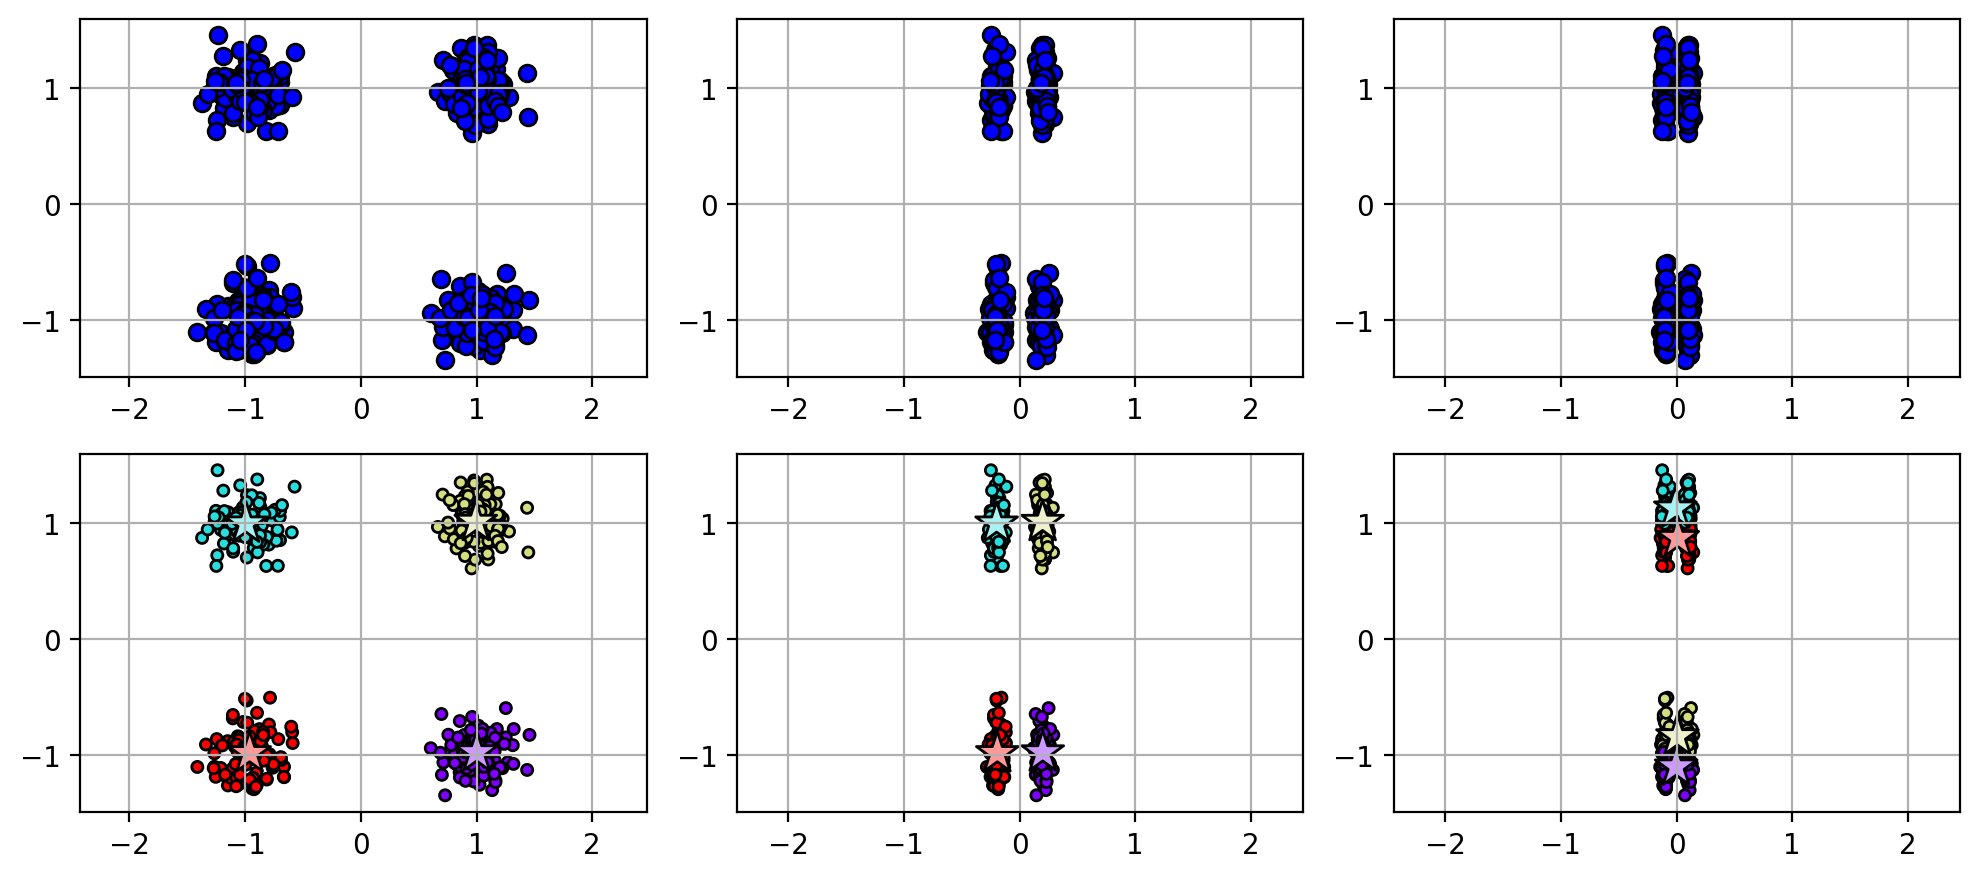

In [48]:
efig